# 04 - Cohort Retention & Churn

**Input**: `clean_transactions.parquet` (notebook 01)

**Output**: `customer_survival.parquet`

---

## Business Context & Objectives

This notebook groups customers into acquisition cohorts, builds a retention matrix, and models time-to-churn using survival analysis. Kaplan-Meier and Cox proportional hazards are standard tools for time-to-event outcomes, and they apply directly to customer lifetime. The question is the same: how long until the event occurs. Both also handle the customers still active at the end of the observation window, rather than forcing them into a binary churned or retained.

The central difficulty is that retail data is non-contractual: there is no cancellation event, so churn has to be defined from the data rather than observed.

### Research questions

1. Does retention differ by acquisition cohort, country, or first-order value?
2. How should churn be defined when there is no explicit end-of-relationship event?
3. Which customer characteristics are associated with faster churn?

### Plan

0. Setup and loading
1. Cohort assignment
2. Retention matrix
3. Defining churn
4. Kaplan-Meier survival curves
5. Cox proportional hazards model
6. Export

# 0. Setup & Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from pathlib import Path
from IPython.display import display, Markdown

PROC = Path("../data/processed")
clean = pd.read_parquet(PROC / "clean_transactions.parquet")

REFERENCE_DATE = clean["InvoiceDate"].max() + pd.Timedelta(1, unit="D")

# Non-cancelled purchases only: a cancelled invoice is not a purchase event
purchases = clean[~clean["IsCancellation"]].copy()

display(Markdown(f"""
### Input
* **Purchase rows (excluding cancellations):** `{len(purchases):,}`
* **Unique customers:** `{purchases['Customer ID'].nunique():,}`
"""))



### Input
* **Purchase rows (excluding cancellations):** `803,001`
* **Unique customers:** `5,854`


**Results.** 803,001 purchase rows covering 5,854 unique customers, after excluding cancellations.

This is 26 customers fewer than the 5,880 in the analytical base from notebook 01. The difference is customers whose only activity was a cancellation, so they have no genuine purchase event. These are the same customers identified as `Frequency = 0` and excluded in notebook 03.

# 1. Cohort Assignment

A customer's cohort is the calendar month of their first purchase.

In [2]:
first_purchase = purchases.groupby("Customer ID")["InvoiceDate"].min().rename("FirstPurchaseDate")

# Drop before merging so the cell can be re-run without creating _x / _y suffixes.
purchases = purchases.drop(columns=["FirstPurchaseDate"], errors="ignore")
purchases = purchases.merge(first_purchase, on="Customer ID")

purchases["CohortMonth"] = purchases["FirstPurchaseDate"].dt.to_period("M")
purchases["InvoiceMonth"] = purchases["InvoiceDate"].dt.to_period("M")
purchases["MonthsSinceAcquisition"] = (
    (purchases["InvoiceMonth"] - purchases["CohortMonth"]).apply(lambda x: x.n)
)

cohort_counts = purchases.groupby("CohortMonth")["Customer ID"].nunique()
total_customers = cohort_counts.sum()
cohort_summary = pd.DataFrame(
    {
        "Acquired Customers": cohort_counts,
        "Share (%)": (cohort_counts / total_customers * 100).round(2),
    }
)
cohort_summary.index.name = "Cohort Month"

display(Markdown("### Cohort Sizes (Customers Acquired per Month)"))
display(
    cohort_summary.style.format(
        {"Acquired Customers": "{:,}", "Share (%)": "{:.2f}%"}
    )
)

### Cohort Sizes (Customers Acquired per Month)

,Acquired Customers,Share (%)
Cohort Month,,
2009-12,951,16.25%
2010-01,368,6.29%
2010-02,375,6.41%
2010-03,441,7.53%
2010-04,294,5.02%
2010-05,255,4.36%
2010-06,267,4.56%
2010-07,186,3.18%
2010-08,163,2.78%


**Results.** The December 2009 cohort holds 951 customers, 16.25% of the base, but is not a genuine acquisition month: it absorbs every customer already active before the dataset begins. It is excluded from any cohort comparison.

Acquisition declines markedly between the two years. Setting aside December, 2010 cohorts range from 163 to 441 customers, while 2011 cohorts range from 72 to 221, roughly half the volume. The sharpest contrast is January: 368 customers in 2010 against 72 in 2011.

A seasonal pattern is visible in both years, with acquisition rising from September to November (239, 375, 326 in 2010; 188, 221, 192 in 2011) before dropping in December. The final cohort, 28 customers, covers nine days only.

This decline is an observation, not an explanation. It could reflect market saturation, a change in commercial strategy, or simply that 2011 buyers were already customers in 2010 and therefore do not count as newly acquired. The data cannot separate these.

The asymmetry matters for the retention matrix below: later cohorts are observed for a shorter period and structurally have fewer populated columns. Survival analysis in sections 4 and 5 handles this through censoring; the matrix does not.

# 2. Retention Matrix

For each cohort, what share of its customers made at least one purchase in each subsequent month?

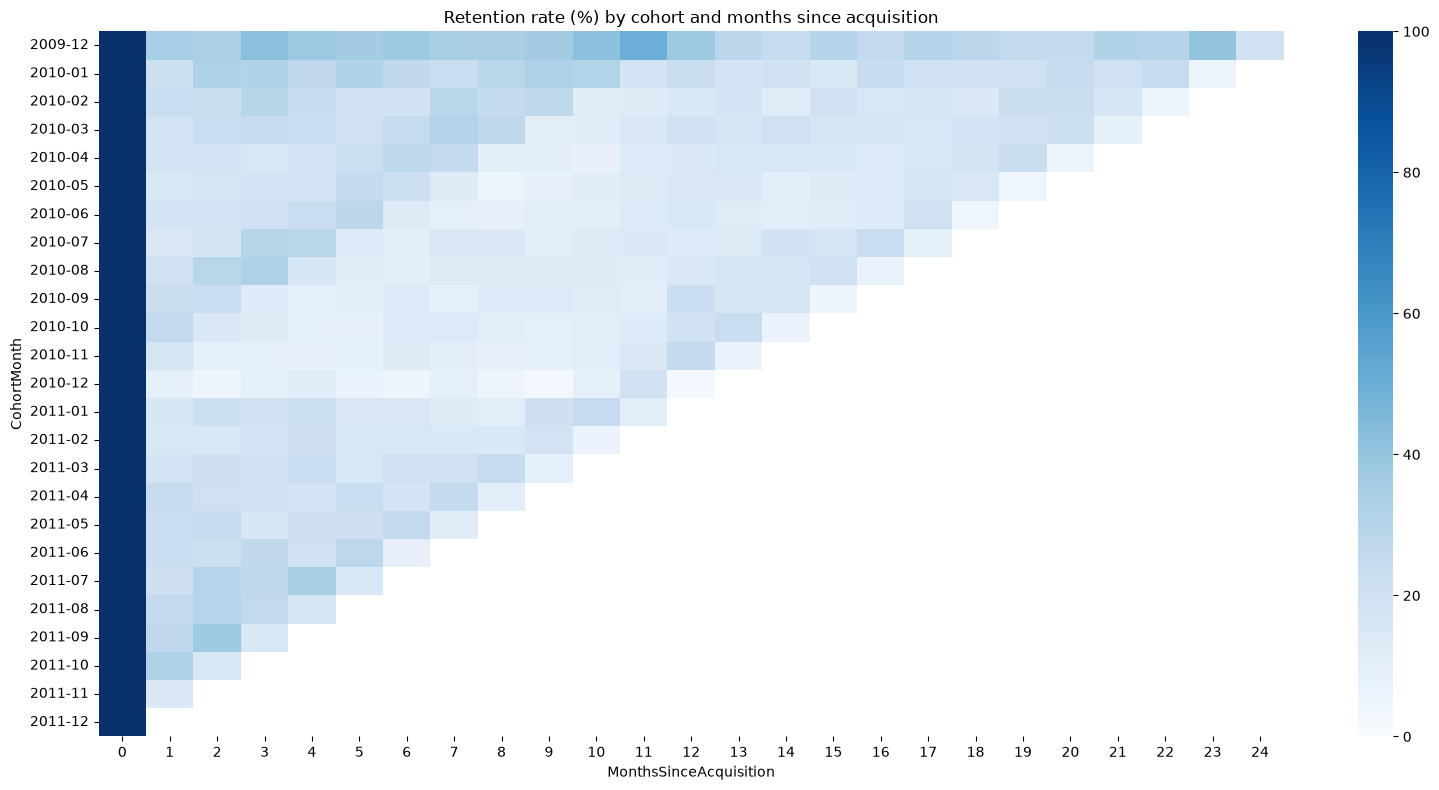

### Retention matrix (first 6 months)

MonthsSinceAcquisition,0,1,2,3,4,5,6
CohortMonth,,,,,,,
2009-12,100.0,35.0,33.3,42.5,38.1,36.0,37.7
2010-01,100.0,21.5,32.1,31.5,27.2,31.2,26.9
2010-02,100.0,23.5,22.7,29.3,24.5,19.7,19.2
2010-03,100.0,19.0,23.1,24.3,23.4,20.4,24.9
2010-04,100.0,19.0,19.0,16.0,18.4,22.1,27.6
2010-05,100.0,15.7,16.9,17.6,17.6,25.5,21.2
2010-06,100.0,17.6,18.7,20.6,23.2,28.5,12.7
2010-07,100.0,15.6,18.3,29.6,29.0,14.0,11.3
2010-08,100.0,19.6,28.8,32.5,16.6,11.7,9.8


In [3]:
cohort_activity = (
    purchases.groupby(["CohortMonth", "MonthsSinceAcquisition"])["Customer ID"]
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_activity.pivot(index="CohortMonth", columns="MonthsSinceAcquisition", values="Customer ID")
retention_matrix = cohort_pivot.divide(cohort_pivot[0], axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(retention_matrix, annot=False, cmap="Blues", vmin=0, vmax=100, ax=ax)
ax.set_title("Retention rate (%) by cohort and months since acquisition")
plt.tight_layout()
plt.show()

display(Markdown("### Retention matrix (first 6 months)"))
display(retention_matrix.iloc[:, :7].round(1))


**Results.** First-month retention sits between 15% and 27% for most cohorts, which is normal for non-contractual retail. Two cohorts fall outside that band: December 2009 at 35.0%, inflated by pre-existing customers, and December 2010 at 9.2%, the weakest in the dataset.

The more informative pattern is not first-month retention but its decay. Cohorts acquired between October and December 2010 start within the normal band, then collapse: October 2010 falls from 25.9% to 14.7%, 12.5% and 8.8% over four months, and November 2010 from 17.5% to 9.5% and 7.7%. These customers were acquired successfully and then lost, which is a different problem from failing to convert them at all.

The 2011 cohorts recover and hold between 15% and 30% across six months without that collapse, with September 2011 reaching 37.8% in month 2.

One hypothesis for the late-2010 pattern is seasonal purchasing, customers acquired around Christmas who buy once and do not return. The data cannot confirm it: an equally plausible reading is a change in acquisition channel or in the product mix over that period. The observation is reported; the cause is not established.

Missing values in the lower right are structural. A cohort acquired in November 2011 cannot be observed at month 6 when the dataset ends on 9 December 2011.

# 3. Defining Churn

There is no cancellation event in this dataset. Customers simply stop purchasing, so churn has to be defined through an inactivity threshold, chosen from the observed distribution of purchase intervals rather than by convention.

**Customers with 2+ purchases:** `4,234` / `5,854` (`72.3%`)

**Gaps of 0 days (same-day invoices):** `3,970` / `30,664` (`12.9%`)

### Distribution of inter-purchase gaps (days)

count    30664.000000
mean        51.826800
std         75.934158
min          0.000000
25%          7.000000
50%         25.000000
75%         62.000000
max        714.000000
Name: InvoiceDate, dtype: float64

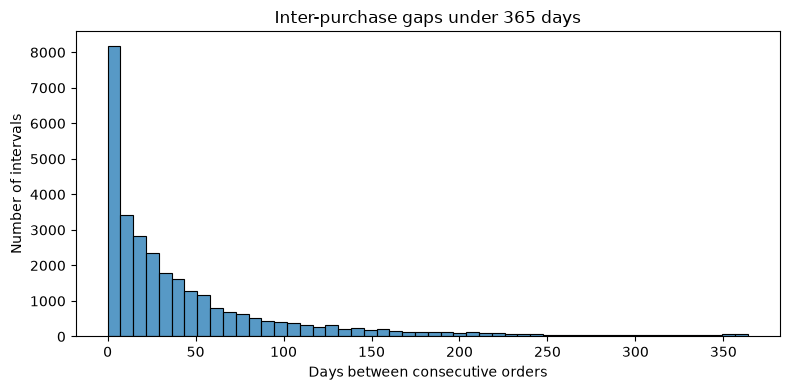

* **50th percentile:** `25` days

* **75th percentile:** `62` days

* **90th percentile:** `136` days

* **95th percentile:** `207` days

In [4]:
# Inter-purchase interval: gap between consecutive orders, customers with 2+ purchases only.
# Single-purchase customers are filtered out BEFORE computing gaps: applying .diff() to a
# single-date series returns an empty Series, and pandas' .apply() does not reliably preserve
# empty-Series results across a mixed-length groupby, causing a TypeError in pd.concat.
# Counting distinct invoices, not distinct timestamps: 65 invoices carry lines recorded
# seconds apart (identified in notebook 02) and would otherwise count twice.
purchase_counts = purchases.groupby("Customer ID")["Invoice"].nunique()
multi_purchase_customers = purchase_counts[purchase_counts >= 2].index
multi = purchases[purchases["Customer ID"].isin(multi_purchase_customers)]

def compute_gaps(dates):
    d = pd.Series(sorted(dates.unique()))
    return d.diff().dt.days.dropna()

all_gaps = multi.groupby("Customer ID")["InvoiceDate"].apply(compute_gaps).reset_index(drop=True)

display(Markdown(
    f"**Customers with 2+ purchases:** `{len(multi_purchase_customers):,}` / `{purchase_counts.shape[0]:,}` "
    f"(`{len(multi_purchase_customers)/purchase_counts.shape[0]:.1%}`)"
))

# Same-day gaps are likely split orders rather than genuine repeat purchases:
# quantify them before reading the lower quantiles.
n_zero = (all_gaps == 0).sum()
display(Markdown(
    f"**Gaps of 0 days (same-day invoices):** `{n_zero:,}` / `{len(all_gaps):,}` "
    f"(`{n_zero/len(all_gaps):.1%}`)"
))

display(Markdown("### Distribution of inter-purchase gaps (days)"))
display(all_gaps.describe())

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(all_gaps[all_gaps < 365], bins=50, ax=ax)
ax.set_title("Inter-purchase gaps under 365 days")
ax.set_xlabel("Days between consecutive orders")
ax.set_ylabel("Number of intervals")
plt.tight_layout()
plt.show()

for pct in [50, 75, 90, 95]:
    display(Markdown(f"* **{pct}th percentile:** `{all_gaps.quantile(pct/100):.0f}` days"))

**Results.** 4,234 of 5,854 customers (72.3%) made two or more purchases, giving 30,664 observed intervals.

The distribution decays smoothly from a peak at 0 to 7 days, with no second mode. No natural cut-off separates active from lapsed customers, which is why the churn threshold has to be a stated convention rather than a discovered boundary.

**3,970 intervals are exactly 0 days, 12.9% of the total.** These are two invoices on the same day, more plausibly a split order than a genuine repeat purchase. Together with a 25th percentile at 7 days, they pull the lower end of the distribution down without reflecting a distinct customer behaviour. They are left in, since removing them would require a rule for distinguishing a split order from two genuine same-day purchases, and no field in the data supports that distinction.

The distribution is heavily right-skewed: median 25 days against a mean of 51.8, maximum 714. Percentiles are 62 days at the 75th, 136 at the 90th, and 207 at the 95th.

**Threshold decision: 180 days.** This sits between the 90th and 95th percentiles. A customer crossing it has gone quiet by the standards of this customer base, since only 7 to 10% of genuine repeat purchases take that long. A shorter threshold would classify normal seasonal buyers as churned; a longer one would leave almost everyone permanently active.

The threshold is derived from this distribution rather than from a round number such as 90 or 365 days.

## 3.1 Building the Survival Dataset

Survival analysis needs two variables per customer. `Event` records whether churn was observed, and `Duration` records the time until either the event or the end of observation.

Censoring is the point of the method. A customer whose last purchase falls within 180 days of the reference date has not necessarily churned. The outcome simply has not been observed yet. Treating them as retained would overstate retention, and excluding them would discard most of the sample.

In [5]:
CHURN_THRESHOLD_DAYS = 180

customer_survival = purchases.groupby("Customer ID").agg(
    FirstPurchaseDate=("FirstPurchaseDate", "first"),
    LastPurchaseDate=("InvoiceDate", "max"),
    Country=("Country", "first"),
    NPurchases=("Invoice", "nunique"),
).reset_index()

# Right-censoring: a customer whose last purchase falls within the churn threshold of the
# reference date has NOT necessarily churned, the outcome simply has not been observed yet.
# event=1 means churn was observed, event=0 means censored.
days_since_last = (REFERENCE_DATE - customer_survival["LastPurchaseDate"]).dt.days
customer_survival["Event"] = (days_since_last > CHURN_THRESHOLD_DAYS).astype(int)

# Time to event, measured consistently across both groups.
# For a churned customer, the event does not occur at the last purchase but once the
# inactivity threshold is crossed, so the threshold is added to the observed activity span.
# For a censored customer, time is measured up to the reference date.
customer_survival["Duration"] = np.where(
    customer_survival["Event"] == 1,
    (customer_survival["LastPurchaseDate"] - customer_survival["FirstPurchaseDate"]).dt.days
        + CHURN_THRESHOLD_DAYS,
    (REFERENCE_DATE - customer_survival["FirstPurchaseDate"]).dt.days
)

display(Markdown(
    f"**Observed churn events:** `{customer_survival['Event'].sum():,}` / "
    f"`{len(customer_survival):,}` (`{customer_survival['Event'].mean()*100:.1f}%`)"
))
display(customer_survival[["Duration", "Event"]].describe())

**Observed churn events:** `2,380` / `5,854` (`40.7%`)

,Duration,Event
count,5854.000000,5854.000000
mean,375.892381,0.406560
std,228.797515,0.491233
min,1.000000,0.000000
25%,180.000000,0.000000
50%,346.500000,0.000000
75%,599.750000,1.000000
max,739.000000,1.000000


Two checks on the resulting variables: how many customers record a duration of zero, and how many purchased only once. The two are related, since a customer with a single purchase has no elapsed activity span.

In [6]:
zero_duration = (customer_survival["Duration"] == 0).sum()
single_purchase = (customer_survival["NPurchases"] == 1).sum()

display(Markdown(f"""
* **Customers with `Duration = 0`:** `{zero_duration:,}` (`{zero_duration/len(customer_survival):.1%}`)
* **Single-purchase customers:** `{single_purchase:,}` (`{single_purchase/len(customer_survival):.1%}`)
"""))


* **Customers with `Duration = 0`:** `0` (`0.0%`)
* **Single-purchase customers:** `1,620` (`27.7%`)


**Results.** 2,380 of 5,854 customers (40.7%) are observed to churn under the 180-day threshold. The remaining 59.3% are censored, meaning the outcome has not been observed rather than that the customer is loyal.

Duration is measured consistently across both groups. For a churned customer, the event occurs when the inactivity threshold is crossed, 180 days after the last purchase, so the threshold is added to the observed activity span. For a censored customer, time runs to the reference date.

Durations average 375.9 days with a median of 346.5 and a maximum of 739. The minimum is 1 day, and the 25th percentile sits at 180, the floor for any single-purchase customer who churned.

1,620 customers (27.7%) purchased only once. They dominate the lower part of the distribution, and the distinction between a failed acquisition and genuine attrition is one this model cannot make.

# 4. Kaplan-Meier Survival Curves

Kaplan-Meier estimates the retention probability over time while accounting for censored observations.

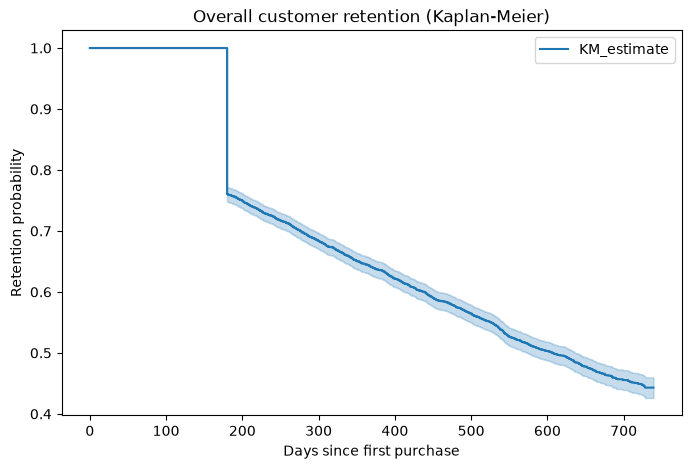

**Median survival time:** `607.0` days

In [7]:
kmf = KaplanMeierFitter()
kmf.fit(customer_survival["Duration"], event_observed=customer_survival["Event"])

fig, ax = plt.subplots(figsize=(8, 5))
kmf.plot_survival_function(ax=ax)
ax.set_title("Overall customer retention (Kaplan-Meier)")
ax.set_xlabel("Days since first purchase")
ax.set_ylabel("Retention probability")
plt.show()

display(Markdown(f"**Median survival time:** `{kmf.median_survival_time_}` days"))


**Results.** Median survival time is 607 days. Half of customers are still active roughly twenty months after their first purchase, which is a usable headline figure for a non-contractual retailer.

The curve starts at 1.00 and declines steadily, with the steepest fall from day 180 onwards, when single-purchase customers begin crossing the inactivity threshold.

Confidence bands widen towards the end of the window, where few customers remain under observation and each remaining event moves the estimate more.

## 4.1 Stratification by First-Order Value

Does spending more on a first purchase predict staying longer?

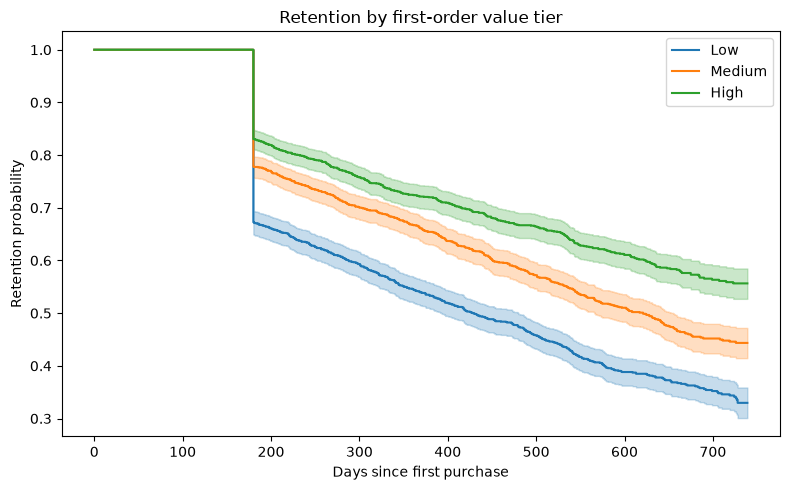

**Log-rank test (Low vs. High tier), p-value:** `0.0000`

### First-order value distribution

count     5854.00
mean       411.35
std        720.84
min          0.00
25%        168.64
50%        295.68
75%        453.05
max      33167.80
Name: FirstOrderValue, dtype: float64

In [8]:
# First-order value: total revenue of the customer's first invoice, not the first line.
# groupby().first() would return a single line, which understates multi-line orders.
first_invoice = (
    purchases.sort_values("InvoiceDate")
    .groupby("Customer ID")["Invoice"]
    .first()
    .rename("FirstInvoice")
)
first_order_value = (
    purchases.merge(first_invoice, on="Customer ID")
    .query("Invoice == FirstInvoice")
    .groupby("Customer ID")["LineRevenue"]
    .sum()
    .rename("FirstOrderValue")
)

# Drop before merging so the cell can be re-run without creating _x / _y suffixes.
customer_survival = customer_survival.drop(columns=["FirstOrderValue"], errors="ignore")
customer_survival = customer_survival.merge(first_order_value, on="Customer ID")
customer_survival["ValueTier"] = pd.qcut(
    customer_survival["FirstOrderValue"], 3, labels=["Low", "Medium", "High"]
)

fig, ax = plt.subplots(figsize=(8, 5))
for tier in ["Low", "Medium", "High"]:
    mask = customer_survival["ValueTier"] == tier
    kmf_tier = KaplanMeierFitter()
    kmf_tier.fit(
        customer_survival.loc[mask, "Duration"],
        event_observed=customer_survival.loc[mask, "Event"],
        label=tier,
    )
    kmf_tier.plot_survival_function(ax=ax)
ax.set_title("Retention by first-order value tier")
ax.set_xlabel("Days since first purchase")
ax.set_ylabel("Retention probability")
plt.tight_layout()
plt.show()

groups = customer_survival["ValueTier"]
results = logrank_test(
    customer_survival.loc[groups == "Low", "Duration"],
    customer_survival.loc[groups == "High", "Duration"],
    customer_survival.loc[groups == "Low", "Event"],
    customer_survival.loc[groups == "High", "Event"],
)
display(Markdown(f"**Log-rank test (Low vs. High tier), p-value:** `{results.p_value:.4f}`"))

display(Markdown("### First-order value distribution"))
display(customer_survival["FirstOrderValue"].describe().round(2))


The test above compares the low and high tiers only, leaving the middle tier out. A three-group test uses all the data and detects a difference located anywhere among the tiers, not just at the extremes.

In [9]:
from lifelines.statistics import multivariate_logrank_test

mlr = multivariate_logrank_test(
    customer_survival["Duration"],
    customer_survival["ValueTier"],
    customer_survival["Event"],
)
display(Markdown(f"**Multivariate log-rank across the three tiers, p-value:** `{mlr.p_value:.4f}`"))

**Multivariate log-rank across the three tiers, p-value:** `0.0000`

**Results.** Both log-rank tests are highly significant: p < 0.0001 comparing the low and high tiers, and p < 0.0001 across all three. Retention differs by first-order value tier.

First-order value ranges from £0 to £33,168 with a median of £296 and a mean of £411. The distribution is heavily right-skewed, so the three tiers hold equal customer counts but very unequal monetary widths: the bottom tier spans £0 to £169, the top from roughly £453 upwards.

The effect is real, but its magnitude needs qualifying, which the Cox model does in section 5.

# 5. Cox Proportional Hazards Model

Kaplan-Meier compares groups one variable at a time. Cox regression estimates the effect of several covariates simultaneously, each expressed as a hazard ratio, provided the proportional-hazards assumption holds.

In [10]:
cox_data = customer_survival[["Duration", "Event", "FirstOrderValue", "NPurchases", "Country"]].copy()

# Keep the top countries only; group the long tail to avoid an unstable model
# with dozens of near-empty dummy categories.
top_countries = cox_data["Country"].value_counts().nlargest(5).index
cox_data["Country"] = cox_data["Country"].where(cox_data["Country"].isin(top_countries), "Other")

reference_country = sorted(cox_data["Country"].unique())[0]
display(Markdown(f"**Reference category for country dummies:** `{reference_country}`"))

cox_data = pd.get_dummies(cox_data, columns=["Country"], drop_first=True)

cph = CoxPHFitter()
cph.fit(cox_data, duration_col="Duration", event_col="Event")

display(Markdown("### Cox model summary (unstratified, see assumption check below)"))
display(cph.summary.round(4))

**Reference category for country dummies:** `Belgium`

### Cox model summary (unstratified, see assumption check below)

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
FirstOrderValue,-0.0000,1.0000,0.0000,-0.0001,0.0001,0.9999,1.0001,0.0,-0.2214,0.8248,0.2780
NPurchases,-0.6031,0.5471,0.0157,-0.6340,-0.5723,0.5305,0.5642,0.0,-38.3656,0.0000,inf
Country_France,-0.1243,0.8831,0.3815,-0.8720,0.6235,0.4181,1.8655,0.0,-0.3257,0.7446,0.4254
Country_Germany,-0.6108,0.5429,0.3671,-1.3304,0.1087,0.2644,1.1148,0.0,-1.6638,0.0961,3.3787
Country_Other,-0.2341,0.7913,0.3301,-0.8810,0.4128,0.4144,1.5111,0.0,-0.7093,0.4782,1.0644
Country_Spain,-0.5804,0.5596,0.4473,-1.4571,0.2963,0.2329,1.3448,0.0,-1.2976,0.1944,2.3628
Country_United Kingdom,-0.2396,0.7869,0.3171,-0.8611,0.3818,0.4227,1.4650,0.0,-0.7557,0.4498,1.1526


**Results.** In the unstratified model, `NPurchases` dominates: coefficient -0.6031, hazard ratio 0.547, z = -38.4, p indistinguishable from zero. Each additional purchase is associated with a 45% reduction in churn hazard.

`FirstOrderValue` shows no effect at all: coefficient -0.0000, hazard ratio 1.0000, p = 0.8248, with a confidence interval running from 0.9999 to 1.0001, tightly centred on 1.

This contradicts the log-rank test in section 4.1, which was highly significant. The two results are reconciled by confounding. The log-rank compares value tiers without controlling for anything else, so it captures both the effect of first-order value and whatever value shares with purchase frequency. Customers placing a larger opening order also tend to order more often, and once frequency enters the model, value has nothing left to explain.

No country coefficient reaches significance. Germany comes closest at p = 0.0961, and every hazard-ratio confidence interval includes 1. Coefficients are read against Belgium, the reference category.

None of these figures can be interpreted yet. The proportional-hazards assumption is checked below, and `NPurchases`, the one variable carrying signal, is the one most likely to violate it.

## 5.1 Checking the Proportional-Hazards Assumption

Cox regression assumes each covariate's effect on the hazard is constant over time. If that fails, the estimated hazard ratio averages an effect that actually changes, and cannot be interpreted as a single number.

In [11]:
cph.check_assumptions(cox_data, p_value_threshold=0.05, show_plots=False)


The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'NPurchases' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'NPurchases' might be incorrect. That is, there may
be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'NPurchases' using pd.cut, and then specify it in
`strata=['NPurchases', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumpti

[]

**Results.** `NPurchases` fails the proportional-hazards test with p below 5e-05. Every other covariate passes.

Its effect on churn hazard is not constant over time, so the hazard ratio of 0.547 cannot be read at face value.

This is expected rather than surprising. `NPurchases` counts purchases across the whole observation period, so it is partly determined by how long the customer survived: a customer active for two years mechanically has more opportunities to buy than one who left after a month. The variable is closer to an outcome than to a fixed baseline characteristic, which is precisely when proportionality breaks down.

lifelines offers three corrections: respecify the functional form, add a time interaction, or stratify. Stratification is taken here, binning `NPurchases` into quartiles and letting the baseline hazard vary freely across them. This removes frequency from the coefficient estimates and asks a cleaner question: within customers of comparable purchase frequency, does anything else predict churn?

## 5.2 Stratified Model

`NPurchases` is binned into quartiles and passed as a stratum rather than a covariate. The baseline hazard is then free to differ across frequency groups, and the remaining coefficients estimate effects within customers of comparable purchase frequency.

In [12]:
cox_data["PurchaseBin"] = pd.qcut(cox_data["NPurchases"], 4, labels=False, duplicates="drop")
display(Markdown(
    f"**Strata created:** `{cox_data['PurchaseBin'].nunique()}` "
    f"(4 requested; fewer if quartile boundaries collide)"
))

cph_stratified = CoxPHFitter()
cph_stratified.fit(
    cox_data.drop(columns=["NPurchases"]),
    duration_col="Duration",
    event_col="Event",
    strata=["PurchaseBin"],
)

display(Markdown("### Cox model, stratified by NPurchases quartile"))
display(cph_stratified.summary.round(4))

cph_stratified.check_assumptions(cox_data.drop(columns=["NPurchases"]), p_value_threshold=0.05, show_plots=False)


**Strata created:** `3` (4 requested; fewer if quartile boundaries collide)

### Cox model, stratified by NPurchases quartile

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
FirstOrderValue,-0.0001,0.9999,0.0000,-0.0001,0.0000,0.9999,1.0000,0.0,-1.3148,0.1886,2.4068
Country_France,-0.3708,0.6902,0.3816,-1.1187,0.3771,0.3267,1.4580,0.0,-0.9718,0.3312,1.5944
Country_Germany,-0.6728,0.5103,0.3671,-1.3923,0.0466,0.2485,1.0477,0.0,-1.8331,0.0668,3.9042
Country_Other,-0.3301,0.7188,0.3302,-0.9773,0.3171,0.3763,1.3731,0.0,-0.9997,0.3174,1.6554
Country_Spain,-0.7165,0.4885,0.4474,-1.5933,0.1603,0.2033,1.1739,0.0,-1.6016,0.1093,3.1942
Country_United Kingdom,-0.3737,0.6882,0.3172,-0.9954,0.2479,0.3696,1.2813,0.0,-1.1784,0.2386,2.0671


Proportional hazard assumption looks okay.


[]

**Results.** Stratification produced **three strata rather than four**. `NPurchases` is concentrated on low values, so two quartile boundaries collide and `duplicates="drop"` merges them. Frequency is therefore controlled more coarsely than intended, but the assumption is satisfied.

The proportional-hazards assumption now holds: lifelines reports that it looks okay.

No covariate is significant. `FirstOrderValue` sits at p = 0.1886 with a hazard ratio of 0.9999 and a confidence interval reaching 1.0000. Germany is the closest country at p = 0.0668, Spain at p = 0.1093, and every interval includes 1.

**Conclusion.** Purchase frequency is the only variable in this dataset carrying signal for time-to-churn. First-order value produces a strong univariate difference between tiers, p < 0.0001 by log-rank, but that difference is entirely attributable to its correlation with purchase frequency: it vanishes at p = 0.82 unstratified and p = 0.19 stratified. Country carries no effect at any stage.

A negative result obtained twice, once with frequency in the model and once with frequency stratified out, is stronger than a single non-significant test. It rules out first-order basket size as an independent predictor rather than merely failing to establish it.

**Practical implication.** Targeting retention effort by first-order basket size would be targeting a proxy for purchase frequency, less accurately than targeting frequency directly. A strategy encouraging a fast second and third order is better supported by this data.

**Not tested here.** The macro-cluster from notebook 03 is not included as a covariate. It is built from Recency, Frequency and Monetary, so it would be largely collinear with `NPurchases` and with the duration variable itself. Testing it properly would require rebuilding the clusters on the observation window alone.

# 6. Export

In [13]:
cols = ["Customer ID", "Duration", "Event", "FirstOrderValue", "NPurchases", "Country", "ValueTier"]
customer_survival[cols].to_parquet(PROC / "customer_survival.parquet", index=False)
display(Markdown(f"Saved `{len(customer_survival):,}` customer survival records to `customer_survival.parquet`"))


Saved `5,854` customer survival records to `customer_survival.parquet`

**Results.** 5,854 customer survival records written to `customer_survival.parquet`, carrying duration, event indicator, first-order value, purchase count, country and value tier.

---

# 7. Summary

**Key findings.**

| Metric | Value |
|---|---|
| Customers analysed | 5,854 |
| Customers with 2+ purchases | 4,234 (72.3%) |
| Same-day intervals | 3,970 (12.9%) |
| Median interval between purchases | 25 days |
| Churn threshold retained | 180 days |
| Observed churn events | 2,380 (40.7%) |
| Median duration | 346.5 days |
| Median survival time | 607 days |
| Median first-order value | £296 |
| Log-rank across value tiers | p < 0.0001 |
| Cox, each additional purchase | Hazard ratio 0.547, p < 0.0001 |
| Cox, first-order value, unstratified | Hazard ratio 1.0000, p = 0.8248 |
| Cox, first-order value, stratified | Hazard ratio 0.9999, p = 0.1886 |

**Headline finding.** Purchase frequency is the only variable carrying signal for time-to-churn. First-order value produces a strong univariate difference between tiers, but it disappears entirely once frequency is controlled for: the tier effect is a proxy for how often a customer orders, not an effect of how much they spent first.

**Limitations.**

1,620 customers (27.7%) purchased once and never returned. The model treats a failed acquisition and a genuine lapse as the same event. An alternative would be to restrict the survival analysis to customers with at least two purchases and treat single-purchase customers as a separate acquisition problem.

The churn threshold is a modelling choice, not an observed fact. At 180 days it sits between the 90th and 95th percentiles of observed intervals. The inter-purchase distribution decays smoothly with no second mode, so no natural cut-off exists and any threshold is a stated convention. Every figure in this notebook, including the 607-day median survival, would shift with a different threshold.

12.9% of observed intervals are same-day, likely split orders rather than repeat purchases. They are retained for lack of a defensible rule to identify them, and they compress the lower quantiles of the interval distribution.

`NPurchases` is partly determined by how long a customer survived, since a longer relationship offers more opportunities to buy. This is why it violates the proportional-hazards assumption, and stratification contains the problem without fully resolving the ambiguity.

Quartile stratification on `NPurchases` produced three strata rather than four, because the variable is concentrated on low values and two quartile boundaries collide. Frequency is therefore controlled more coarsely than intended.

Censoring affects 59.3% of the sample, which limits the precision of every estimate, particularly in the right tail of the survival curve.

The December 2009 cohort is not comparable to the others, since it absorbs all pre-existing customers. The December 2011 cohort covers nine days.

**Scope note.** This notebook works from `clean_transactions.parquet` only. It analyses 5,854 customers, those with at least one non-cancelled purchase, while notebook 03 segments 5,838 customers, excluding those with non-positive net revenue. The two exclusion rules answer different questions and are not intended to align.